In [127]:
# data
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
import random

words = open('./data/names.txt', 'r').read().splitlines()
v = sorted(list(set(''.join(words))))
encode = { c:i+1 for i,c in enumerate(v) }
encode['.'] = 0
decode = { i:c for c,i in encode.items() }

context_length = 3
def gen_dataset(words):
    X, Y = [], []
    for w in words:
        window = [0] * context_length;
        for c in w + '.':
            X.append(window)
            Y.append(encode[c])
            # print(''.join(decode[i] for i in window), '-->', decode[encode[c]])
            window = window[1:] + [encode[c]]
    X, Y = torch.tensor(X), torch.tensor(Y) # X:(N,C) Y:(N)
    return X, Y

random.seed(42)
random.shuffle(words)
n1, n2 = int(0.8*len(words)), int(0.9*len(words))
Xtr, Ytr = gen_dataset(words[:n1])
Xdev, Ydev = gen_dataset(words[n1:n2])
Xte, Yte = gen_dataset(words[n2:])

N= 182625 N_mini= 32
params 17697
loss_train 2.2898004055023193
loss_test 2.3114571571350098


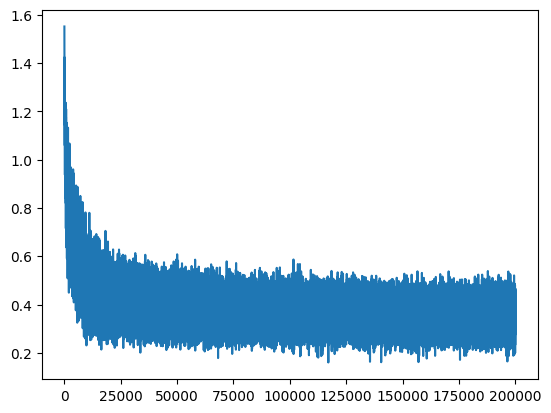

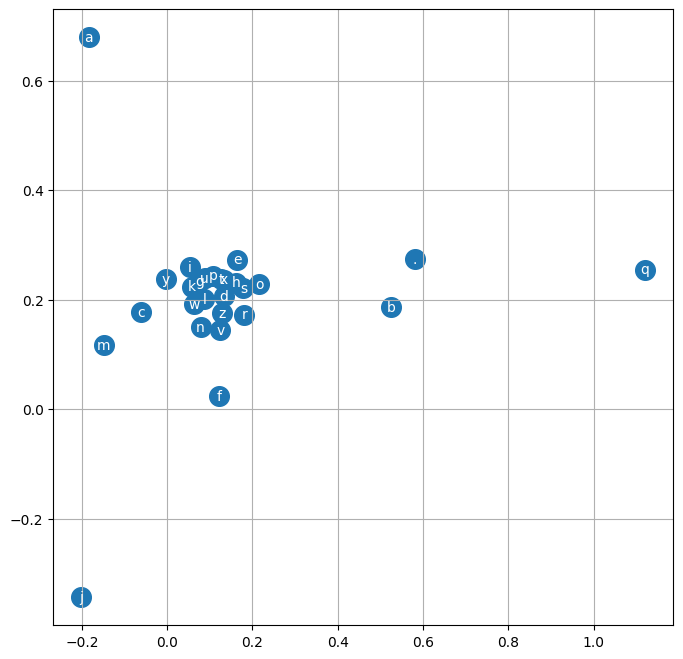

In [128]:
# model + training
g = torch.Generator().manual_seed(2147483647)
V, N, N_mini, E = len(encode.items()), Xtr.shape[0], 32, 10
CxE = context_length * E
print("N=", N, "N_mini=", N_mini)

# -model
C = torch.randn((V,E), generator=g) # embed in R^2 (V:27,E:2)
W1, b1 = torch.randn((CxE,300), generator=g), torch.randn(300, generator=g)
W2, b2 = torch.randn((300,V), generator=g), torch.randn(V, generator=g)
params = [C, W1, b1, W2, b2]
print("params", sum(p.nelement() for p in params))
for p in params:
    p.requires_grad = True

losses = []
steps = []
for i in range(200000):
    # -forward
    ix_mini = torch.randint(0, N, (N_mini,))
    X_mini, Y_mini = Xtr[ix_mini], Ytr[ix_mini]
    h1 = torch.tanh(C[X_mini].view(-1,CxE) @ W1 + b1) # (-1=32,3,2)->(N:32,C*E:6) @ (C*E:6,100) = (32,100)
    logits = (h1 @ W2) + b2 # R (32,100) @ (100,27) + (1,27) = (32,27)
    # y_hat = logits.exp() / logits.exp().sum(1, keepdims=True) # softmax = R+/normalize
    # loss = -y_hat[torch.arange(32), Y].log().mean() # note: pluck out probs?
    loss = F.cross_entropy(logits, Y_mini) # fused kernels, numerical stability
    # print(loss.item())

    # -backward
    for p in params:
        p.grad = None
    loss.backward()
    # -update
    for p in params:
        p.data += -0.01 * p.grad

    steps.append(i)
    losses.append(loss.log10().item())

plt.plot(steps, losses)

h1 = torch.tanh(C[Xtr].view(-1,CxE) @ W1 + b1) # (32,3,2)->(N:32,C*E:6) @ (C*E:6,100) = (32,100)
logits = (h1 @ W2) + b2 # R (32,100) @ (100,27) + (1,27) = (32,27)
loss = F.cross_entropy(logits, Ytr) # fused kernels, numerical stability
print("loss_train", loss.item())

h1 = torch.tanh(C[Xdev].view(-1,CxE) @ W1 + b1) # (32,3,2)->(N:32,C*E:6) @ (C*E:6,100) = (32,100)
logits = (h1 @ W2) + b2 # R (32,100) @ (100,27) + (1,27) = (32,27)
loss = F.cross_entropy(logits, Ydev) # fused kernels, numerical stability
print("loss_test", loss.item())

plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), decode[i], ha="center", va="center", color="white")
plt.grid('minor')

In [130]:
# inference
i_terminal = 0
for _ in range(20):
    output = []
    window = [0] * context_length
    while True:
        emb = C[torch.tensor([context])]
        h1 = torch.tanh(emb.view(1,-1) @ W1 + b1) # (32,3,2)->(N:32,C*E:6) @ (C*E:6,100) = (32,100)
        logits = (h1 @ W2) + b2 # R (32,100) @ (100,27) + (1,27) = (32,27)
        y_hat = F.softmax(logits, dim=1)

        i = torch.multinomial(y_hat, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [i]
        output.append(decode[i])
        if i == i_terminal:
            break
    print(''.join(output))

i.
kaush.
ihlenja.
vyann.
blthi.
iha.
izane.
baya.
izah.
ihlayna.
izareela.
izet.
.
weylea.
iza.
izan.
ihlyilahmio.
izun.
ihe.
ihanney.
